## Natural Language Processing

### Project: Movie review sentiment analysis
### Submitted by: Aditya Gupta

We will be dealing with movie review data that includes both positive and negative reviews in this assignment. We will use Sentiment Analysis to assess if a given review is positive or negative using the provided dataset.

Therefore, we will make use of Naive Bayes algorithm to perform sentiment analysis on the movie review dataset.

## Importing the Libraries

In [41]:
import numpy as np
import math
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
import warnings
import seaborn as sns
nltk.download('punkt')
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\adik4\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\adik4\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## Reading the data

When reading the data, ensure that the '.csv' file is in the same location where your jupyter notebook is used. This way the files are organized and easy to read using the pandas library. 

In [42]:
## Reading the data and removing columns that are not important. 
df = pd.read_csv("movie_reviews.csv", sep = ',', encoding = 'latin-1')

In [43]:
 # print head of data frame with help of head function
df.head() 

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,"Petter Mattei's ""Love in the Time of Money"" is...",positive
4,"Probably my all-time favorite movie, a story o...",positive


## Count plot of the output categories: positive or negative

Feel free to take a look at the output and whether the classes are balanced or imbalanced. 

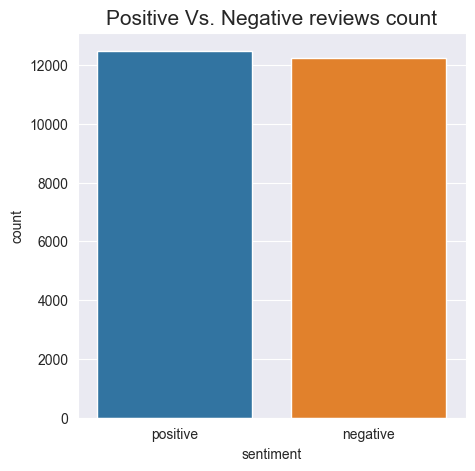

In [44]:
plt.figure(figsize = (5,5))
sns.countplot(data=df,x="sentiment")
plt.title("Positive Vs. Negative reviews count", fontsize = 15)
plt.show()


## Upsampling the minority class:

It is known that Naive bayes is not robust to class imbalance. It could be seen above that the data is little imbalanced. Therefore, class balancing can be done before giving it to the Naive Bayes model for prediction.

In [45]:
## hint: use resample from sklearn.utils
from sklearn.utils import resample

df_majority = df.loc[df["sentiment"]=="positive"]
df_minority = df.loc[df["sentiment"]=="negative"]

negative_upsample = resample(df_minority, replace = True, n_samples = df_majority.shape[0], random_state = 101)

df_upsampled = pd.concat([df_majority, negative_upsample])  # concat two data frames i,e majority class data set and upsampled minority class data set
df_upsampled = df_upsampled.sample(frac = 1)

In [46]:
## Just to ensure that upsampling was done successfully, take a look at the shape of the data in 
## this cell. 

# print the shape of data set with the help of shape function having "negative" as class label
df_upsampled.loc[df_upsampled["sentiment"]=="negative"].shape

(12474, 2)

In [47]:
## In this cell, we are going to be dividing the data into train and test points
## Ensure that you store the upsampled data in a variable called 'df_upsampled' 
## so that the below operations are performed successfully


## Considering 10000 positive and 10000 negative data points
negative_data_points_train = df_upsampled[df_upsampled["sentiment"]=="negative"].iloc[:10000]
positive_data_points_train = df_upsampled[df_upsampled["sentiment"]=="positive"].iloc[:10000]

## Considering the remaining data points for test
negative_data_points_test = df_upsampled[df_upsampled["sentiment"]=="negative"].iloc[10000:]
positive_data_points_test = df_upsampled[df_upsampled["sentiment"]=="positive"].iloc[10000:]

## Concatenate the training positive and negative reviews
X_train = pd.concat([positive_data_points_train["review"], negative_data_points_train["review"]])
## Concatenating the training positive and negative outputs
y_train = pd.concat([positive_data_points_train["sentiment"], negative_data_points_train["sentiment"]])

## Concatenating the test positive and negative reviews
X_test = pd.concat([positive_data_points_test["review"], negative_data_points_test["review"]])
## Concatenating the test positive and negative outputs
y_test = pd.concat([positive_data_points_test["sentiment"], negative_data_points_test["sentiment"]])


In [48]:
## Take a look at the total number of classes and their count using '.value_counts()' for y_train and y_test.
## Ensure that there are equal number of positive and negative reviews. 
y_train.value_counts()

positive    10000
negative    10000
Name: sentiment, dtype: int64

In [49]:
y_test.value_counts()

positive    2474
negative    2474
Name: sentiment, dtype: int64

## Pre-process the reviews:

We know that a review contains links, punctuation, stopwords and many other words that don't give a lot of meaning for the Naive Bayes model for prediction. 

In the cell below, one must implement text-preprocessing and remove links, punctuations and stopwords. It is also important to lowercase the letters so that 'Admire' and 'admire' are not treated as different words. 

In addition to this, perform stemming operation so that similar words are reduced. To know more about stemming, feel free to take a look at this link.


In [50]:
# TASK CELL

def clean_review(review):
    '''
    Input:
        review: a string containing a review.
    Output:
        review_cleaned: a processed review. 

    '''
    #1.Remove extra spaces
    review1=re.sub(" +"," ",review)
    
    #1.Remove punctuations
    review2=re.sub(r'[^\w\s]','',review1)
    
    #3.Remove hyperlinks
    review3=re.sub(r'http\S+','',review2)
    
    #4.Remove special characters
    review4=re.sub("[^A-Za-z0-9.]+"," ",review3)
    
    #5.Lowercasing
    review5=review4.lower()
    
    #6.Tokenization
    tokens=word_tokenize(review5)
    
    #7.Removing stopwords
    stop_words=set(stopwords.words('english'))
    new_review=[i for i in tokens if not i in stop_words] 
    
    #8.Stemming
    ps=PorterStemmer()
    new_rev = [ps.stem(word) for word in new_review]
    
    #Creating sentence from list of words
    review_cleaned=' '.join(word for word in new_rev)

    return review_cleaned

##  Implement a find_occurrence function:

In this function, we find the total occurrence of a word giving information such as label, word and frequency dictionary.

Note that this function is used later in the code when we are going to be predicting the output using Naive Bayes. 

In [51]:
# TASK CELL
def find_occurrence(frequency, word, label):
    '''
    Params:
        frequency: a dictionary with the frequency of each pair (or tuple)
        word: the word to look up
        label: the label corresponding to the word
    Return:
        n: the number of times the word with its corresponding label appears.
    '''
    n=0
    if (word,label) in frequency:
        n=frequency[(word,label)]
  
    return n

### Converting output to numerical format:

We have outputs as 'positive' or 'negative'. In the cell below, we convert it to a numerical format. 

In [52]:
## With the use of mapping function, we replace
## the label in the form of string to an integer. 

output_map = {'positive': 0, 'negative': 1}
y_train = y_train.map(output_map)
y_test = y_test.map(output_map)

In [53]:
## Ensuring that there are equal number of classes on the training data. 
y_train.value_counts()

0    10000
1    10000
Name: sentiment, dtype: int64

In [54]:
## Choosing a random review and taking a look at it.
X_train.iloc[0]

"This is a truly great film, with excellent direction. The core plot element, the painting of mila's ass is captivating. I really can't express in words just how much I enjoyed watching Mila getting her ass painted repeatedly.<br /><br />Connor"

From the above cell output, it could be seen that there are a lot of words that don't add a lot of meaning to the text. 

Therefore, those words would be removed. It also reduces the computation time. 

Therefore, it is a good practice we are following.

In [55]:
custom_review = X_train.iloc[0]

# print cleaned review
print(clean_review(custom_review))

truli great film excel direct core plot element paint mila ass captiv realli cant express word much enjoy watch mila get ass paint repeatedlybr br connor


We now use this function to pre-process the review and remove words that don't add a lot of meaning in our model. 

## Implementing review counter function

It is now time to implement the count function for the reviews. 

In this function, we count the occurrence of words and get the probabilities 
for the words based on the training data. 

In other words, we get the probability of occurrence of a word, given that the output is 'positive'.

Similarly, we also compute the probability of occurence of a word, given that the output is 'negative'.



In [56]:
# TASK CELL
def review_counter(output_occurrence, reviews, positive_or_negative):
    '''
    Params:
        output_occurrence: a dictionary that will be used to map each pair to its frequency
        reviews: a list of reviews
        positive_or_negative: a list corresponding to the sentiment of each review (either 0 or 1)
    Return:
        output: a dictionary mapping each pair to its frequency
    '''
    ## Steps :
    # define the key, which is the word and label tuple
    # if the key exists in the dictionary, increment the count
    # else, if the key is new, add it to the dictionary and set the count to 1
    
    for label, review in zip(positive_or_negative, reviews):
      split_review = clean_review(review).split()
      for word in split_review:
        # Your code here
        key=(word,label)
        if key in output_occurrence:
            output_occurrence[key]=output_occurrence[key]+1
        else:
            output_occurrence[key]=1
   
    return output_occurrence
   


### Test your function with example reviews:

Feel free to run the cell below and understand whether the above function that you have defined is producing the optimum results. 

In [57]:
# Testing your function

result = {}
reviews = ['got bored throught the moview', 'The movie was fantastic', 'Will not watch it again', 'Was bored, it was a complete waste of time and money', 'Enjoyed the movie to the fullest']
ys = [1, 0, 1, 1, 0]
review_counter(result,reviews, ys)

{('got', 1): 1,
 ('bore', 1): 2,
 ('throught', 1): 1,
 ('moview', 1): 1,
 ('movi', 0): 2,
 ('fantast', 0): 1,
 ('watch', 1): 1,
 ('complet', 1): 1,
 ('wast', 1): 1,
 ('time', 1): 1,
 ('money', 1): 1,
 ('enjoy', 0): 1,
 ('fullest', 0): 1}

In [58]:
# Build the freqs dictionary for later uses

freqs = review_counter({}, X_train, y_train)

In [59]:
## Run this cell to get an idea about the corpus of words and their occurrence along with labels. 
## In this, we are computing the frequency of occurrence of word given that a review is 'positive'.
## Similarly, we also compute the frequence of occurence of word given that a review is 'negative'.
freqs

{('truli', 0): 824,
 ('great', 0): 5112,
 ('film', 0): 19914,
 ('excel', 0): 1443,
 ('direct', 0): 1398,
 ('core', 0): 95,
 ('plot', 0): 1910,
 ('element', 0): 500,
 ('paint', 0): 173,
 ('mila', 0): 6,
 ('ass', 0): 79,
 ('captiv', 0): 130,
 ('realli', 0): 4251,
 ('cant', 0): 1192,
 ('express', 0): 332,
 ('word', 0): 694,
 ('much', 0): 3676,
 ('enjoy', 0): 2126,
 ('watch', 0): 5038,
 ('get', 0): 5075,
 ('repeatedlybr', 0): 1,
 ('br', 0): 22237,
 ('connor', 0): 33,
 ('cours', 0): 1105,
 ('experienc', 0): 129,
 ('review', 0): 701,
 ('like', 0): 7994,
 ('stuff', 0): 414,
 ('star', 0): 1604,
 ('war', 0): 1292,
 ('profession', 0): 166,
 ('crap', 0): 126,
 ('definit', 0): 935,
 ('drag', 0): 153,
 ('movi', 0): 17263,
 ('say', 0): 2574,
 ('bad', 0): 1410,
 ('comment', 0): 632,
 ('teen', 0): 233,
 ('comedi', 0): 1484,
 ('awesom', 0): 270,
 ('stori', 0): 5520,
 ('good', 0): 5937,
 ('actingbr', 0): 21,
 ('josi', 0): 22,
 ('gellar', 0): 4,
 ('play', 0): 3978,
 ('well', 0): 4677,
 ('drew', 0): 101,


## Training the Naive Bayes Model

Now we are in the training phase of the Naive Bayes algorithm. In this cell, take a look at the ways to calculate the log likelihood and log prior values as these are important for testing in the next few cells. 

Also calculate the frequency of occurrence of words where the output is negative. In the same way, calculate the word frequency count using the above functions in order to compute the log likelihood.

Return the logprior and loglikelihood output by the model from this function. 

In [60]:
def train_naive_bayes(freqs, train_x, train_y):
    '''
    Input:
        freqs: dictionary from (word, label) to how often the word appears
        train_x: a list of reviews
        train_y: a list of labels correponding to the reviews (0,1)
    Output:
        logprior: the log prior. (equation 3 above)
        loglikelihood: the log likelihood of you Naive bayes equation. (equation 6 above)
    '''
    loglikelihood = {}
    logprior = 0


    # calculate V, the number of unique words in the vocabulary
    vocab = set([key[0] for key in list(freqs.keys())])
    V = len(vocab)

    # calculate num_pos and num_neg - the total number of positive and negative words for all documents
    num_pos = num_neg = 0
    for pair in freqs.keys():
        # if the label is zero
        if pair[1]==0:

            # Increment the number of positive words by the count for this (word, label) pair
            num_pos = num_pos+freqs[pair]

        # else, the label is negative
        else:

            # increment the number of negative words by the count for this (word,label) pair
            num_neg = num_neg+freqs[pair]

    # Calculate num_doc, the number of documents
    num_doc = len(train_y)

    # Calculate D_pos, the number of positive documents 
    pos_num_docs = len(y_train.loc[y_train==0])

    # Calculate D_neg, the number of negative documents 
    neg_num_docs = len(y_train.loc[y_train==1])

    # Calculate logprior
    logprior = np.log(neg_num_docs) - np.log(pos_num_docs)

    # For each word in the vocabulary...
    for word in vocab:
        # get the positive and negative frequency of the word
        if (word,0) in freqs:
            freq_pos=freqs[(word,0)]
        else:
            freq_pos=0
        if (word,1) in freqs:
            freq_neg=freqs[(word,1)]
        else:
            freq_neg=0

        # calculate the probability that each word is positive, and negative
        p_w_pos = (freq_pos+1)/(num_pos+V)
        p_w_neg = (freq_neg+1)/(num_neg+V)

        # calculate the log likelihood of the word
        loglikelihood[word] = np.log(p_w_neg/p_w_pos)


    return logprior, loglikelihood

In [61]:
# You do not have to input any code in this cell, but it is relevant to grading, so please do not change anything
logprior, loglikelihood = train_naive_bayes(freqs, X_train, y_train)
print(logprior)
print(len(loglikelihood))

0.0
74320


In [62]:
#storing model parameters in text file
with open('loglikelihood.txt','w') as fp:
    fp.write(str(loglikelihood))
    
with open('logprior.txt','w') as fp:
    fp.write(str(logprior))

##  Implementing Naive Bayes Predict Function:

It is now time to make our prediction as to whether a given review is negative or positive respectively. 

After adding the log likelihood values, ensure that the output is 1 (negative) if the sum of the log likelihood value is greater than 0 and 0 (positive) if the sum of the log likelihood is less than or equal to 0. 

In [63]:
# TASK 4 CELL

def naive_bayes_predict(review, logprior, loglikelihood):
    '''
    Params:
        review: a string
        logprior: a number
        loglikelihood: a dictionary of words mapping to numbers
    Return:
        total_prob: the sum of all the loglikelihoods of each word in the review (if found in the dictionary) + logprior (a number)

    '''
    
      # process the review to get a list of words
    word_l = clean_review(review).split()

    # initialize probability to zero
    total_prob = 0

    # add the logprior
    total_prob = total_prob+logprior

    for word in word_l:

        # check if the word exists in the loglikelihood dictionary
        if word in loglikelihood:
            # add the log likelihood of that word to the probability
            total_prob = total_prob+loglikelihood[word]


    return 0 if total_prob<=0 else 1

In [64]:
# You do not have to input any code in this cell, but it is relevant to grading, so please do not change anything

# Experiment with your own review.
my_review = "I thought this series was going to be another fun, action series with some dynamic plots and great performances. I was wrong. While I like Jamie Denton, this show is hardly worth watching at all, unless you enjoy watching some people brutalized and the actions of the agents supposedly warranted under the theme of national security. The show is great propaganda for the current government, and spews out jingoism as though we talk that way every day. After a couple of episodes, it was boring the hell out of me, and I started watching reruns of House Invaders on BBCAmerica instead. Rather watch CSI and Without a Trace, without a doubt."
p = naive_bayes_predict(my_review, logprior, loglikelihood)
print('The expected output is', p)

The expected output is 1


## Implementing Naive Bayes Test function:

In this function, implement the previous functions such as naive_bayes_predict to get the predictions for the test set. 

In addition to this, the function should return the total number of reviews that it correctly classified as 'positive' or 'negative'. 

In [71]:
# UNQ_C6 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)

from sklearn.metrics import confusion_matrix

def test_naive_bayes(test_x, test_y, logprior, loglikelihood):
    """
    Input:
        test_x: A list of reviews
        test_y: the corresponding labels for the list of reviews
        logprior: the logprior
        loglikelihood: a dictionary with the loglikelihoods for each word
    Output:
        accuracy: (# of reviews classified correctly)/(total # of reviews)
        error: error of the model
        results: confusion matrix of the model
        false_pos: reviews misclassified as false positive
        false_neg: reviews misclassified as false negative
    """
    accuracy = 0  

    
    y_hats = []
    for review in test_x:
        # if the prediction is > 0
        if  naive_bayes_predict(review, logprior, loglikelihood)>0:
            # the predicted class is 1
            y_hat_i = 1
        else:
            # otherwise the predicted class is 0
            y_hat_i = 0

        # append the predicted class to the list y_hats
        y_hats.append(y_hat_i)

    # error is the average of the absolute values of the differences between y_hats and test_y
    error = np.mean(np.absolute(y_hats-test_y))

    accuracy = 1-error
    
    # renaming actual and predicted values
    test_y = pd.Series(test_y, name='Actual')
    y_hats = pd.Series(y_hats, name='Predicted')

    #create confusion matrix
    results=confusion_matrix(test_y, y_hats)
    
    # storing false positive and false negative reviews
    false_pos=[]
    false_neg=[]
    for i in range(len(test_y)):
        false_positives = np.logical_and(test_y.iloc[i] != y_hats.iloc[i], y_hats.iloc[i] == 0)
        if false_positives==True:
            false_pos.append(test_x.iloc[i])
        
        false_negatives = np.logical_and(test_y.iloc[i] != y_hats.iloc[i], y_hats.iloc[i] == 1)
        if false_negatives==True:
            false_neg.append(test_x.iloc[i])

    return accuracy,error,results,false_pos,false_neg

In [66]:
# For grading purpose only
# You do not have to input any code in this cell, but it is relevant to grading, so please do not change anything

# Run this cell to test your function

for review in ["If you like original gut wrenching laughter you will like this movie. If you are young or old then you will love this movie, hell even my mom liked it.<br /><br />Great Camp!!!",
                "What a waste of talent. A very poor, semi-coherent, script cripples this film. Rather unimaginative direction, too. Some VERY faint echoes of Fargo here, but it just doesn't come off.",
                "I have seen this film at least 100 times and I am still excited by it, the acting is perfect and the romance between Joe and Jean keeps me on the edge of my seat, plus I still think Bryan Brown is the tops. Brilliant Film.",
                "Cheap, amateurish, unimaginative, exploitative... but don't think it'll have redeeming amusement value. About as unentertaining, uninstructive and just plain dull as a film can be."]:
    p = naive_bayes_predict(review, logprior, loglikelihood)
    print(f'{review[:100]} -> {p:.2f}')


If you like original gut wrenching laughter you will like this movie. If you are young or old then y -> 0.00
What a waste of talent. A very poor, semi-coherent, script cripples this film. Rather unimaginative  -> 1.00
I have seen this film at least 100 times and I am still excited by it, the acting is perfect and the -> 0.00
Cheap, amateurish, unimaginative, exploitative... but don't think it'll have redeeming amusement val -> 1.00


In [67]:
# Feel free to check the sentiment of your own review below
my_review = ['The moview was very boring, I wanted to leave in the middle']
for my_review in my_review:
    p=naive_bayes_predict(my_review, logprior, loglikelihood)
    print(p)

1


#  Evaluate the accuracy
1. Split your data into training and test sets using random selection. Set the seed as parameter of the function so that user can select a different training and test set by changin seed.

2. Calculate model paramters with training set.

3. Print confusion matrix for training and test set.

4. Examine False Positive and False Negative cases and provide reasoning why they get misclassified.

In [68]:
#part 1: Split your data into training and test sets using random selection. Set the seed as parameter of the
    #function so that user can select a different training and test set by changin seed
    
def evaluate_model(seed):
    
    """
    Input:
        seed: value of seed for random selection of data
    Output:
        acc_train: accuracy of training set
        error_train: error of training set
        conf_train: confusion matrix of training set
        acc_test: accuracy of test set
        error_test: error of test set
        conf_test: confusion matrix of test set
        false_pos_test: false positive reviews of test set
        false_neg_test: false negative reviews of test set
    """
    
    df_majority = df[df["sentiment"]=="positive"]
    df_minority = df[df["sentiment"]=="negative"]

    negative_upsample = resample(df_minority, replace = True, 
                            n_samples = df_majority.shape[0],
                            random_state = seed)

    df_upsampled = pd.concat([df_majority, negative_upsample])  
    df_upsampled = df_upsampled.sample(frac = 1)

    negative_data_points_train = df_upsampled[df_upsampled["sentiment"]=="negative"].iloc[:10000]
    positive_data_points_train = df_upsampled[df_upsampled["sentiment"]=="positive"].iloc[:10000]
    negative_data_points_test = df_upsampled[df_upsampled["sentiment"]=="negative"].iloc[10000:]
    positive_data_points_test = df_upsampled[df_upsampled["sentiment"]=="positive"].iloc[10000:]

    X_train = pd.concat([negative_data_points_train["review"], positive_data_points_train["review"]])
    y_train = pd.concat([negative_data_points_train["sentiment"], positive_data_points_train["sentiment"]])
    X_test = pd.concat([negative_data_points_test["review"], positive_data_points_test["review"]])
    y_test = pd.concat([negative_data_points_test["sentiment"], positive_data_points_test["sentiment"]])
    
    output_map = {'positive': 0, 'negative': 1}
    y_train = y_train.map(output_map)
    y_test = y_test.map(output_map)
    
    acc_train,error_train,conf_train,false_pos_train,false_neg_train=test_naive_bayes(X_train, y_train, logprior, loglikelihood)
    acc_test,error_test,conf_test,false_pos_test,false_neg_test=test_naive_bayes(X_test, y_test, logprior, loglikelihood)
    
    return acc_train,error_train,conf_train,acc_test,error_test,conf_test,false_pos_test,false_neg_test
    
    

-------------------------------------
Model parameters with training set
Accuracy of training set ->  92.175 %
Error of training set ->  0.07825
-------------------------------------
Model parameters with test set
Accuracy of test set ->  92.17865804365401 %
Error of test set ->  0.07821341956345998
-------------------------------------
Confusion matrix of training set


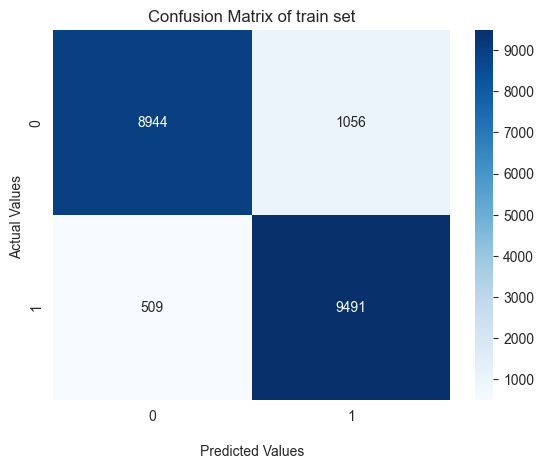

-------------------------------------
Confusion matrix of test set


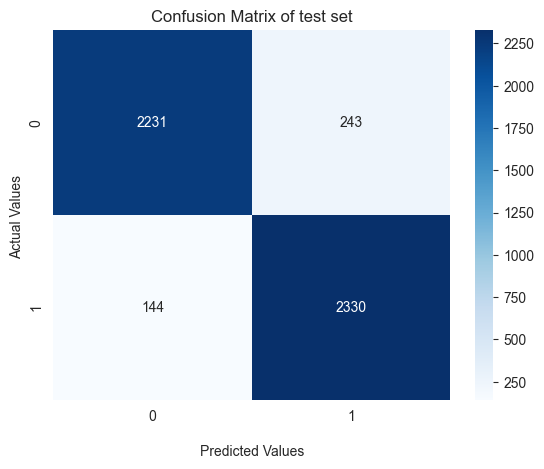

In [69]:
user_seed=int(input("Enter seed value from user "))

#part2: Calculate model paramters with training set

acc_train,error_train,conf_train,acc_test,error_test,conf_test,false_pos_test,false_neg_test=evaluate_model(user_seed)
print("-------------------------------------")
print("Model parameters with training set")
print("Accuracy of training set -> ",acc_train*100,"%")
print("Error of training set -> ",error_train)
print("-------------------------------------")

print("Model parameters with test set")
print("Accuracy of test set -> ",acc_test*100,"%")
print("Error of test set -> ",error_test)

#part3: Print confusion matrix for training and test set
    
print("-------------------------------------")
print("Confusion matrix of training set")
ax1 = sns.heatmap(conf_train,  annot=True, cmap='Blues',fmt='d')
ax1.set_title('Confusion Matrix of train set');
ax1.set_xlabel('\nPredicted Values')
ax1.set_ylabel('Actual Values ');
plt.show()

print("-------------------------------------")
print("Confusion matrix of test set")
ax2 = sns.heatmap(conf_test,  annot=True, cmap='Blues',fmt='d')
ax2.set_title('Confusion Matrix of test set');
ax2.set_xlabel('\nPredicted Values')
ax2.set_ylabel('Actual Values ');
plt.show()

